# Exercise PT-P2 — Neural Network Training & Testing
### Customer Sentiment & Intent Classifier (Keras / TensorFlow)

**Author:** Ram Kelly Jersen Leliza
**Course:** ITC-C508 — Prof. Rodolfo C. Raga Jr., PhDCS
**Institution:** Jose Rizal University

---

**PT-P1 No-Code Baseline to beat:** Accuracy **90.00%** | Weighted F1 **0.9095**

**How to use this notebook:** For every experiment, edit **ONLY the CONFIG block in Section 2**,
then run `Runtime > Restart session and run all`. Section 8 prints a ready-to-copy row
for `Leliza_FFBP_Training_Log_Template.xlsx`.

---
### Fixes applied to the provided baseline script
| # | Issue in provided script | Fix |
|---|---|---|
| 1 | `Embedding(..., input_length=MAX_LEN)` | `input_length` was **removed in Keras 3** (current Colab). Replaced with an explicit `Input(shape=(MAX_LEN,))` layer. |
| 2 | `y_data = df['label'].values` fed to `sparse_categorical_crossentropy` | Labels are **strings**, that loss needs **integers**. Added `LabelEncoder`. |
| 3 | `train_test_split` without `stratify` | With only 160 samples an unstratified split can drop a class from validation. Added `stratify`. |
| 4 | Vocabulary built from the **full** dataset before splitting | That leaks validation/test vocabulary into training. Vocab is now built from the **training split only**. |
| 5 | Only `val_loss` and `val_f1` printed | Added precision, recall, accuracy, best-epoch, training time, and a held-out **test** split evaluation. |


## Section 0 — Environment Setup
Mounts Google Drive and imports all dependencies. Random seeds are fixed so every experiment
difference comes from the hyperparameters, not from random initialisation.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, time, json
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score, precision_score,
                             recall_score, classification_report, confusion_matrix)
from collections import Counter
import matplotlib.pyplot as plt

# --- Reproducibility (Random Seed = 42, logged in the FFBP spreadsheet) ---
SEED = 42
keras.utils.set_random_seed(SEED)      # seeds python, numpy AND tensorflow at once
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)

TensorFlow: 2.20.0
Keras     : 3.13.2


## Section 2 — Hyperparameter Configuration (THE 3 PILLARS)

> **Note on ordering:** this block is numbered *Section 2* to match the handout, but it is placed
> **before** Section 1 because Section 1's tokenizer needs `MAX_LEN` and `MAX_VOCAB_SIZE` from it.

###  THIS IS THE ONLY CELL YOU EDIT BETWEEN EXPERIMENTS

| Pillar | Parameters in CONFIG |
|---|---|
| **Pillar 1 — Architecture** | `embed_dim`, `hidden_dim` |
| **Pillar 2 — Optimization** | `learning_rate`, `batch_size`, `epochs`, `optimizer_type` |
| **Pillar 3 — Regularization** | `dropout_rate` |
| *Preprocessing (Task 4 lever)* | `max_len`, `max_vocab_size` |

In [3]:
# ============================================================
# SECTION 2. HYPERPARAMETER CONFIGURATION
# ============================================================
CONFIG = {
    "run_id":         "EXP-05C-CHAMPION",

    # --- Pillar 1: ARCHITECTURE -------------------------------
    "embed_dim":      24,        # CHANGED: 16 -> 24
    "hidden_dim":     64,        # CHANGED: 48 -> 64

    # --- Pillar 2: OPTIMIZATION -------------------------------
    "learning_rate":  0.001,     # CHANGED: 0.003 -> 0.001 (finer convergence)
    "batch_size":     32,        # CHANGED: 16 -> 32 (less gradient noise)
    "epochs":         120,       # CHANGED: 80 -> 120 (early stopping ends it)
    "optimizer_type": "Adam",    # unchanged

    # --- Pillar 3: REGULARIZATION -----------------------------
    "dropout_rate":   0.25,      # CHANGED: 0.3 -> 0.25

    # --- Early Stopping ---------------------------------------
    "use_early_stopping": True,
    "es_patience":    20,        # CHANGED: 12 -> 20

    # --- Text preprocessing (free-form lever for Task 4) ------
    "max_len":        20,        # unchanged
    "max_vocab_size": 1000,      # CHANGED: 400 -> 1000 (EXP-05B's fatal error)
}

# --- PT-P1 no-code benchmark (Task 1, step 2) -----------------
PTP1_BENCHMARK = {"accuracy": 0.90, "weighted_f1": 0.9095}

# --- Paths ----------------------------------------------------
CSV_FILEPATH = "/content/drive/MyDrive/NN Training/Leliza_PT-P1_Dataset_Final.csv"
PLOT_DIR     = "/content/drive/MyDrive/NN Training/plots"
TEXT_COL, LABEL_COL = "text", "label"

os.makedirs(PLOT_DIR, exist_ok=True)
print(f"Configured run: {CONFIG['run_id']}")

Configured run: EXP-05C-CHAMPION


## Section 1 — Data Loading, Preprocessing & Partitioning
*(Lecture 3 — "Dataset Partitioning and Preprocessing")*

Order of operations matters here: we **split first, then build the vocabulary from the training
split only**. Building the vocabulary from all 160 rows would let words that appear exclusively in
validation/test influence the model's input representation — a subtle form of data leakage that
inflates the reported score.

In [4]:
# ============================================================
# SECTION 1. LOAD & PREPROCESS CSV DATA
# ============================================================
df = pd.read_csv(CSV_FILEPATH)
print(f"Loaded {len(df)} rows from {os.path.basename(CSV_FILEPATH)}\n")
print("Class distribution:")
print(df[LABEL_COL].value_counts().to_string(), "\n")

# --- Encode STRING labels -> INTEGERS (required by sparse_categorical_crossentropy) ---
label_encoder = LabelEncoder()
y_data      = label_encoder.fit_transform(df[LABEL_COL].values)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)
print("Label mapping:", {n: i for i, n in enumerate(class_names)}, "\n")

raw_texts = df[TEXT_COL].astype(str).tolist()

# --- DATASET PARTITIONING: 70% Train / 15% Validation / 15% Test (stratified) ---
txt_train, txt_temp, y_train, y_temp = train_test_split(
    raw_texts, y_data, test_size=0.30, random_state=SEED, stratify=y_data)
txt_val, txt_test, y_val, y_test = train_test_split(
    txt_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"Train: {len(txt_train)} | Validation: {len(txt_val)} | Test: {len(txt_test)}")


# --- Tokenizer & Vocabulary Builder (fitted on TRAIN ONLY) ---
def build_vocab(texts, max_vocab_size):
    """Map each word to an integer index. Index 0 = <PAD>, index 1 = <UNK>."""
    words       = [w.lower() for t in texts for w in str(t).split()]
    word_counts = Counter(words)
    most_common = word_counts.most_common(max_vocab_size - 2)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab


def text_to_sequence(text, vocab, max_len):
    """Convert one string into a fixed-length list of integer token IDs."""
    tokens = str(text).lower().split()
    seq = [vocab.get(tok, 1) for tok in tokens]          # 1 = <UNK> for unseen words
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))                # right-pad with <PAD>
    else:
        seq = seq[:max_len]                              # truncate
    return seq


vocab = build_vocab(txt_train, CONFIG["max_vocab_size"])
VOCAB_SIZE = len(vocab)

encode = lambda texts: np.array([text_to_sequence(t, vocab, CONFIG["max_len"]) for t in texts])
X_train, X_val, X_test = encode(txt_train), encode(txt_val), encode(txt_test)

print(f"Vocabulary size (train-only): {VOCAB_SIZE}")
print(f"Input tensor shape: {X_train.shape}  (samples x max_len)")

Loaded 368 rows from Leliza_PT-P1_Dataset_Final.csv

Class distribution:
label
Positive_Feedback    92
Negative_Feedback    92
Urgent_Support       92
General_Inquiry      92 

Label mapping: {'General_Inquiry': 0, 'Negative_Feedback': 1, 'Positive_Feedback': 2, 'Urgent_Support': 3} 

Train: 257 | Validation: 55 | Test: 56
Vocabulary size (train-only): 657
Input tensor shape: (257, 20)  (samples x max_len)


## Section 3 — Keras Sequential Architecture
*(Lecture 3 — Pillar 1: Architecture)*

**Automated feature extraction happens in the first two layers** — this is the answer to Debrief Q4:

- **`Embedding`** learns a dense `embed_dim`-dimensional vector for every vocabulary word. These
  vectors are *trainable weights*, so the network discovers its own numeric representation of each
  word instead of being handed one. Replaces the manual feature engineering a rule-based system needs.
- **`GlobalAveragePooling1D`** collapses the `(max_len, embed_dim)` sequence into a single
  `(embed_dim,)` document vector by averaging across tokens — a fixed-length sentence fingerprint,
  produced with **zero trainable parameters**.

Only after these two layers does the `Dense` classifier see the data.

In [5]:
# ============================================================
# SECTION 3. KERAS SEQUENTIAL ARCHITECTURE
# ============================================================
model = Sequential(name=CONFIG["run_id"].replace("-", "_"))

# Explicit Input layer (replaces the removed `input_length=` argument in Keras 3)
model.add(Input(shape=(CONFIG["max_len"],), dtype="int32"))

# --- FEATURE EXTRACTION STAGE 1: Embedding (Pillar 1) ---
model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=CONFIG["embed_dim"],
    mask_zero=True,                 # <PAD> tokens are ignored by the pooling layer
    name="embedding"))

# --- FEATURE EXTRACTION STAGE 2: sequence -> single document vector ---
model.add(GlobalAveragePooling1D(name="global_avg_pool"))

# --- CLASSIFICATION HEAD: hidden layer (Pillar 1) ---
model.add(Dense(CONFIG["hidden_dim"], activation="relu", name="hidden_dense"))

# --- REGULARIZATION (Pillar 3) ---
model.add(Dropout(CONFIG["dropout_rate"], name="dropout"))

# --- OUTPUT LAYER: one neuron per class, softmax -> probability distribution ---
model.add(Dense(num_classes, activation="softmax", name="output"))

## Section 4 — Optimizer & Compilation
*(Lecture 3 — Pillar 2: Optimization)*

`model.compile()` attaches the **loss function** (what the Backward Pass differentiates) and the
**optimizer** (the rule that converts gradients into weight updates). No training happens yet.

In [6]:
# ============================================================
# SECTION 4. OPTIMIZER & COMPILATION
# ============================================================
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    loss="sparse_categorical_crossentropy",   # integer labels + softmax output
    optimizer=opt,
    metrics=["accuracy"])

model.summary()

Model: "EXP_05C_CHAMPION"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 24)         │        15,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 24)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense (Dense)            │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,628 (68.86 KB)

 Trainable params: 17,628 (68.86 KB)

 Non-trainable params: 0 (0.00 B)

## Section 5 — The Operational Loop (Training)
*(Lecture 3 — "The NN Training Loop")*

**This single `model.fit()` call is where all four stages of the training loop execute**, repeated
for every mini-batch of every epoch. Keras hides them inside its `train_step`:

| Loop stage | Where it happens |
|---|---|
| 1. Forward Pass | `model(x, training=True)` inside `train_step` |
| 2. Loss Calculation | `sparse_categorical_crossentropy` from Section 4 |
| 3. Backward Pass | `tape.gradient(loss, trainable_weights)` — autodiff backpropagation |
| 4. Weight Update | `optimizer.apply_gradients(...)` using the Section 4 optimizer |
| 5. Epoch Iteration | the `epochs=` argument below |

In [7]:
# ============================================================
# SECTION 5. THE OPERATIONAL LOOP (FIT)
# ============================================================
from keras.callbacks import EarlyStopping

callbacks = []
if CONFIG.get("use_early_stopping", False):
    callbacks.append(EarlyStopping(
        monitor="val_loss",
        patience=CONFIG.get("es_patience", 10),
        restore_best_weights=True,   # rolls the weights back to the best epoch
        verbose=1))

print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks,
    verbose=1)

training_time_min = (time.time() - start_time) / 60
print(f"\nTraining completed in {training_time_min:.2f} minutes")

--- Starting Training Run: EXP-05C-CHAMPION ---
Epoch 1/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.2957 - loss: 1.3844 - val_accuracy: 0.4545 - val_loss: 1.3782
Epoch 2/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6459 - loss: 1.3719 - val_accuracy: 0.6727 - val_loss: 1.3669
Epoch 3/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7704 - loss: 1.3575 - val_accuracy: 0.7455 - val_loss: 1.3512
Epoch 4/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7977 - loss: 1.3366 - val_accuracy: 0.8000 - val_loss: 1.3283
Epoch 5/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8405 - loss: 1.3042 - val_accuracy: 0.8364 - val_loss: 1.2961
Epoch 6/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8560 - loss: 1.2640 - val_accuracy: 0.8364 - val_loss: 1.2546
Epoch 7/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8677 - loss: 1.2085 - val_accuracy: 0.8364 - val_loss: 1.2028
Epoch 8/120
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8872 

## Section 5B — Evaluation Metrics
*(Lecture 3 — "Evaluation Metrics Matrix")*

Weighted averaging is used for precision/recall/F1 so the score accounts for each class's support —
and so it is directly comparable to the PT-P1 weighted F1 of 0.9095.

In [8]:
# ============================================================
# SECTION 5B. EVALUATION METRICS
# ============================================================
def evaluate(X, y, split_name):
    probs = model.predict(X, verbose=0)
    preds = np.argmax(probs, axis=1)
    return {
        "split":     split_name,
        "accuracy":  accuracy_score(y, preds),
        "precision": precision_score(y, preds, average="weighted", zero_division=0),
        "recall":    recall_score(y, preds, average="weighted", zero_division=0),
        "f1":        f1_score(y, preds, average="weighted", zero_division=0),
        "preds":     preds,
    }

train_m = evaluate(X_train, y_train, "Train")
val_m   = evaluate(X_val,   y_val,   "Validation")
test_m  = evaluate(X_test,  y_test,  "Test")

best_epoch = int(np.argmin(history.history["val_loss"])) + 1   # lowest val loss

# When early stopping restores best weights, report metrics from THAT epoch,
# not from the last epoch that happened to run.
if CONFIG.get("use_early_stopping", False):
    final_train_loss = history.history["loss"][best_epoch - 1]
    final_val_loss   = history.history["val_loss"][best_epoch - 1]
else:
    final_train_loss = history.history["loss"][-1]
    final_val_loss   = history.history["val_loss"][-1]

print(f"\n{'='*62}\n  RESULTS — {CONFIG['run_id']}\n{'='*62}")
print(f"{'Split':<12}{'Loss':>10}{'Accuracy':>12}{'Precision':>12}{'Recall':>10}{'F1':>10}")
print("-"*62)
print(f"{'Train':<12}{final_train_loss:>10.4f}{train_m['accuracy']:>12.4f}"
      f"{train_m['precision']:>12.4f}{train_m['recall']:>10.4f}{train_m['f1']:>10.4f}")
print(f"{'Validation':<12}{final_val_loss:>10.4f}{val_m['accuracy']:>12.4f}"
      f"{val_m['precision']:>12.4f}{val_m['recall']:>10.4f}{val_m['f1']:>10.4f}")
print(f"{'Test':<12}{'—':>10}{test_m['accuracy']:>12.4f}"
      f"{test_m['precision']:>12.4f}{test_m['recall']:>10.4f}{test_m['f1']:>10.4f}")
print("-"*62)
print(f"Best epoch (lowest validation loss): {best_epoch} / {CONFIG['epochs']}")

# --- Benchmark comparison against PT-P1 -----------------------
d_acc = val_m["accuracy"] - PTP1_BENCHMARK["accuracy"]
d_f1  = val_m["f1"]       - PTP1_BENCHMARK["weighted_f1"]
print(f"\nvs PT-P1 BASELINE (Acc {PTP1_BENCHMARK['accuracy']:.4f} / "
      f"F1 {PTP1_BENCHMARK['weighted_f1']:.4f})")
print(f"  Accuracy delta : {d_acc:+.4f}  {'BEAT' if d_acc > 0 else 'below baseline'}")
print(f"  F1 delta       : {d_f1:+.4f}  {'BEAT' if d_f1  > 0 else 'below baseline'}")

print(f"\nPer-class report (Validation):\n")
print(classification_report(y_val, val_m["preds"],
                            target_names=class_names, zero_division=0))


  RESULTS — EXP-05C-CHAMPION
Split             Loss    Accuracy   Precision    Recall        F1
--------------------------------------------------------------
Train           0.0869      1.0000      1.0000    1.0000    1.0000
Validation      0.4537      0.8545      0.8603    0.8545    0.8552
Test                 —      0.8929      0.9078    0.8929    0.8921
--------------------------------------------------------------
Best epoch (lowest validation loss): 26 / 120

vs PT-P1 BASELINE (Acc 0.9000 / F1 0.9095)
  Accuracy delta : -0.0455  below baseline
  F1 delta       : -0.0543  below baseline

Per-class report (Validation):

                   precision    recall  f1-score   support

  General_Inquiry       0.86      0.86      0.86        14
Negative_Feedback       0.91      0.77      0.83        13
Positive_Feedback       0.75      0.86      0.80        14
   Urgent_Support       0.93      0.93      0.93        14

         accuracy                           0.85        55
        mac

## Section 6 — Loss Curve Plot & Model Fit Diagnosis
*(Lecture 3 — "Performance Monitoring of Loss Curves" and "Diagnosing Model Fit")*

The plot is saved automatically to Drive so it can be embedded in the IEEE report.
The printed diagnosis is a **heuristic suggestion** — always confirm it against the curve shape.

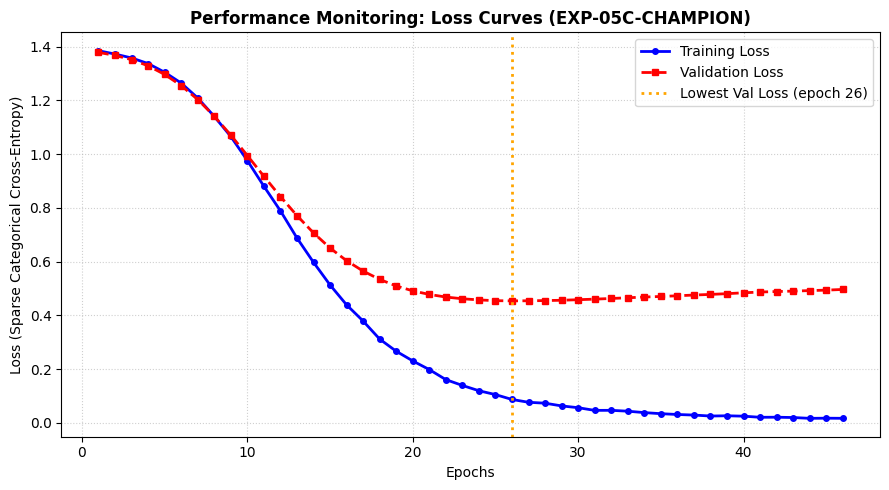

Plot saved: /content/drive/MyDrive/NN Training/plots/EXP-05C-CHAMPION_loss_curve.png

  SUGGESTED DIAGNOSIS: MILD OVERFITTING
  Reason: train/validation loss gap of 0.3668 indicates memorisation starting
  Final Train Loss 0.0869 | Final Val Loss 0.4537


In [9]:
# ============================================================
# SECTION 6. LOSS CURVES + FIT DIAGNOSIS
# ============================================================
train_losses = history.history["loss"]
val_losses   = history.history["val_loss"]
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_losses, label="Training Loss",
         color="blue", linewidth=2, marker="o", markersize=4)
plt.plot(epochs_range, val_losses, label="Validation Loss",
         color="red", linewidth=2, linestyle="--", marker="s", markersize=4)
plt.axvline(best_epoch, color="orange", linestyle=":", linewidth=2,
            label=f"Lowest Val Loss (epoch {best_epoch})")
plt.title(f"Performance Monitoring: Loss Curves ({CONFIG['run_id']})",
          fontsize=12, fontweight="bold")
plt.xlabel("Epochs"); plt.ylabel("Loss (Sparse Categorical Cross-Entropy)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="best")
plt.tight_layout()

plot_path = os.path.join(PLOT_DIR, f"{CONFIG['run_id']}_loss_curve.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")


# --- Automated fit diagnosis heuristic ------------------------
tail = max(3, len(val_losses) // 3)
val_trend = val_losses[-1] - min(val_losses)          # how far val loss rose off its floor
gap       = final_val_loss - final_train_loss

if train_m["accuracy"] < 0.75 and val_m["accuracy"] < 0.75:
    diagnosis = "UNDERFITTING"
    reason    = "both train and validation accuracy stayed low - model lacks capacity or training time"
elif val_trend > 0.05 and train_losses[-1] < train_losses[-tail]:
    diagnosis = "OVERFITTING"
    reason    = (f"validation loss rose {val_trend:.4f} above its minimum (epoch {best_epoch}) "
                 f"while training loss kept falling")
elif gap > 0.30:
    diagnosis = "MILD OVERFITTING"
    reason    = f"train/validation loss gap of {gap:.4f} indicates memorisation starting"
else:
    diagnosis = "GOOD FIT"
    reason    = f"both losses fell and stabilised together (final gap {gap:.4f})"

print(f"\n{'='*62}\n  SUGGESTED DIAGNOSIS: {diagnosis}\n{'='*62}")
print(f"  Reason: {reason}")
print(f"  Final Train Loss {final_train_loss:.4f} | Final Val Loss {final_val_loss:.4f}")

## Section 7 — Direct PT-P1 Comparison (Same 10 Held-Out Phrases)
*(Optional but strongly recommended for the report)*

These are the **exact ten phrases** used to test the no-code Machine Learning for Kids model in
PT-P1. None of them appears in the training CSV, so this is a true apples-to-apples comparison
between the no-code model and this Keras model on identical inputs.

In [10]:
# ============================================================
# SECTION 7. PT-P1 HELD-OUT PHRASE COMPARISON
# ============================================================
ptp1_phrases = [
    ("This sweater is amazing, I get compliments every time I wear it.", "Positive_Feedback", "Positive_Feedback", 84),
    ("The pants ripped after only two wears, total waste of money.",     "Negative_Feedback", "Negative_Feedback", 92),
    ("I was charged twice for my order, please refund me now.",          "Urgent_Support",    "Urgent_Support",    95),
    ("Oh great, another shirt that shrank in the wash.",                 "Negative_Feedback", "Negative_Feedback", 70),
    ("Wow, love how my package still hasn't arrived after three weeks.", "Negative_Feedback", "Urgent_Support",    79),
    ("Fantastic, the zipper broke on day one, just fantastic.",          "Negative_Feedback", "Negative_Feedback", 69),
    ("Do you have this dress in a size large?",                          "General_Inquiry",   "General_Inquiry",  100),
    ("What are your store hours on weekends?",                           "General_Inquiry",   "General_Inquiry",  100),
    ("Can I use two discount codes on one order?",                       "General_Inquiry",   "General_Inquiry",  100),
    ("Do you ship internationally?",                                     "General_Inquiry",   "General_Inquiry",  100),
]

texts    = [p[0] for p in ptp1_phrases]
expected = [p[1] for p in ptp1_phrases]

X_ptp1 = encode(texts)
probs  = model.predict(X_ptp1, verbose=0)
keras_pred = [class_names[i] for i in np.argmax(probs, axis=1)]
keras_conf = (np.max(probs, axis=1) * 100).round(1)

print(f"{'#':<3}{'Expected':<20}{'PT-P1 (no-code)':<26}{'PT-P2 (Keras)':<26}")
print("-"*80)
k_correct = 0
for i, (txt, exp, p1_pred, p1_conf) in enumerate(ptp1_phrases, 1):
    ok = keras_pred[i-1] == exp
    k_correct += ok
    p1_mark = "OK " if p1_pred == exp else "X  "
    k_mark  = "OK " if ok else "X  "
    print(f"{i:<3}{exp:<20}{p1_mark}{p1_pred} ({p1_conf}%)".ljust(49)
          + f"{k_mark}{keras_pred[i-1]} ({keras_conf[i-1]}%)")

y_exp  = label_encoder.transform(expected)
y_pred = label_encoder.transform(keras_pred)
print("-"*80)
print(f"PT-P1 no-code : 9/10 correct = 90.0% | Weighted F1 0.9095")
print(f"PT-P2 Keras   : {k_correct}/10 correct = {k_correct*10:.1f}% | "
      f"Weighted F1 {f1_score(y_exp, y_pred, average='weighted', zero_division=0):.4f}")

#  Expected            PT-P1 (no-code)           PT-P2 (Keras)             
--------------------------------------------------------------------------------
1  Positive_Feedback   OK Positive_Feedback (84%)OK Positive_Feedback (51.79999923706055%)
2  Negative_Feedback   OK Negative_Feedback (92%)OK Negative_Feedback (96.69999694824219%)
3  Urgent_Support      OK Urgent_Support (95%)   OK Urgent_Support (98.9000015258789%)
4  Negative_Feedback   OK Negative_Feedback (70%)OK Negative_Feedback (91.80000305175781%)
5  Negative_Feedback   X  Urgent_Support (79%)   OK Negative_Feedback (37.70000076293945%)
6  Negative_Feedback   OK Negative_Feedback (69%)OK Negative_Feedback (79.5%)
7  General_Inquiry     OK General_Inquiry (100%) OK General_Inquiry (98.19999694824219%)
8  General_Inquiry     OK General_Inquiry (100%) OK General_Inquiry (95.0999984741211%)
9  General_Inquiry     OK General_Inquiry (100%) OK General_Inquiry (86.9000015258789%)
10 General_Inquiry     OK General_Inquiry (100%) 

## Section 8 — FFBP Experiment Log Row
*(Lecture 3 — "The Excel-based Training Experiment Logs")*

Copy the values below straight into
`Leliza_FFBP_Training_Log_Template.xlsx`, one row per experiment.

In [11]:
# ============================================================
# SECTION 8. FFBP TRAINING LOG ROW (copy into Excel)
# ============================================================
log_row = {
    "Run ID":                CONFIG["run_id"],
    "Date":                  pd.Timestamp.today().strftime("%Y-%m-%d"),
    "Dataset":               "Leliza_PT-P1 (160 samples, 4 classes)",
    "Input Features":        CONFIG["max_len"],
    "Hidden Layers":         1,
    "Neurons per Layer":     CONFIG["hidden_dim"],
    "Output Neurons":        num_classes,
    "Activation Function":   "ReLU / Softmax",
    "Learning Rate":         CONFIG["learning_rate"],
    "Optimizer":             CONFIG["optimizer_type"],
    "Loss Function":         "Sparse Categorical Cross Entropy",
    "Epochs":                CONFIG["epochs"],
    "Batch Size":            CONFIG["batch_size"],
    "Train Loss":            round(final_train_loss, 4),
    "Validation Loss":       round(final_val_loss, 4),
    "Train Accuracy (%)":    round(train_m["accuracy"] * 100, 2),
    "Validation Accuracy (%)": round(val_m["accuracy"] * 100, 2),
    "Precision":             round(val_m["precision"], 4),
    "Recall":                round(val_m["recall"], 4),
    "F1-Score":              round(val_m["f1"], 4),
    "Training Time (min)":   round(training_time_min, 2),
    "Early Stopping Epoch":  best_epoch,
    "Random Seed":           SEED,
    "Status":                "Completed",
    "Notes":                 f"{diagnosis}. embed_dim={CONFIG['embed_dim']}, "
                             f"dropout={CONFIG['dropout_rate']}. {reason}",
}

print("="*72)
print(f"  FFBP LOG ROW — {CONFIG['run_id']}")
print("="*72)
for k, v in log_row.items():
    print(f"{k:<26}: {v}")
print("="*72)

# Tab-separated line — paste directly into one Excel row
print("\nTAB-SEPARATED (paste into Excel):\n")
print("\t".join(str(v) for v in log_row.values()))

  FFBP LOG ROW — EXP-05C-CHAMPION
Run ID                    : EXP-05C-CHAMPION
Date                      : 2026-08-11
Dataset                   : Leliza_PT-P1 (160 samples, 4 classes)
Input Features            : 20
Hidden Layers             : 1
Neurons per Layer         : 64
Output Neurons            : 4
Activation Function       : ReLU / Softmax
Learning Rate             : 0.001
Optimizer                 : Adam
Loss Function             : Sparse Categorical Cross Entropy
Epochs                    : 120
Batch Size                : 32
Train Loss                : 0.0869
Validation Loss           : 0.4537
Train Accuracy (%)        : 100.0
Validation Accuracy (%)   : 85.45
Precision                 : 0.8603
Recall                    : 0.8545
F1-Score                  : 0.8552
Training Time (min)       : 0.26
Early Stopping Epoch      : 26
Random Seed               : 42
Status                    : Completed
Notes                     : MILD OVERFITTING. embed_dim=24, dropout=0.25. train/vali